# 04 · Entrenamiento del predictor del día siguiente

**Requiere TensorFlow** (Google Colab, o un entorno local con
`requirements.txt` instalado, ver README, sección "Entorno").

Dos pasos, con separacion temporal estricta. Primero se selecciona la
arquitectura por el ERROR EN VALIDACIÓN (nunca en test); despues, con esa
arquitectura ya fijada, se comparan los generadores en el test final.

1. **Elegir arquitectura** (enunciado, paso 4): con SOLO la ventana real
   disponible para entrenar (sin ningún día sintético), se comparan
   constante / baseline / lineal / densa / CNN / CNN profunda / RNN / RNN
   profunda — misma comparación que `Taller_con_Datos_SP500_promedio.ipynb`,
   pero con nuestros bancos y 2 canales por banco (retorno + volatilidad
   realizada). La tabla generada `04_comparacion_arquitecturas.csv`
   incluye metricas de validacion (`split=validation`).

   **El modelo `constante`** (predecir siempre la media por banco del
   train, ignorando X) es la referencia decisiva. El otro suelo,
   `baseline`, repite el retorno del día anterior; como los retornos
   diarios son casi incorrelados en el tiempo, eso es *activamente* peor
   que no predecir nada, y comparar solo contra él hace que cualquier red
   parezca buena. Una red que no bate a `constante` no ha aprendido
   ninguna señal de la ventana X: solo el nivel medio.
2. **Rejilla años de sintéticos × generador**: con la arquitectura
   ganadora, se entrena una versión por cada combinación
   (`SYNTH_DEPTH_YEARS_GRID` años de backfill sintético añadidos) ×
   (generador que rellenó esos años), evaluando siempre en el MISMO test
   real (`REAL_TEST_HOLDOUT_START_DATE` en adelante). Ese test no se usa
   para decidir la arquitectura.

**Sobre las fechas** (ver `src/config.py`): la ventana real de
`REAL_INTRADAY_YEARS` (~5,5 años) se reparte en train/val/test, val y
test se comen el último año, así que lo que queda para entrenar "solo con
reales" son ~4,6 años (`synth_years=0`). A partir de ahí, `synth_years` cuenta
hacia atrás desde `REAL_INTRADAY_START_DATE` cuánta historia con
volatilidad SINTÉTICA se añade, el final del entrenamiento
(`VAL_START_DATE`) es siempre el mismo, no cambia con la profundidad.

**Sobre la métrica, MAE como *loss*, no solo como número final**: la
diapositiva de teoría del taller ("REAL PROBLEM",
`2026_Taller_Generativos.pdf` pág. 11-12) especifica **"Learning:
minimize MAE"** para el problema real que motiva el taller, y reporta el
error en las unidades del target (Kelvin), la ventaja de MAE frente a
MSE, que queda en unidades al cuadrado. El retorno diario es igual de
heavy-tailed que ese problema (ver notebook 02: la Gaussiana no
reproduce el pico leptocúrtico de los datos reales), así que entrenar
con MSE dejaría que los pocos días de retorno extremo dominen el
gradiente. Por eso aquí se entrena con `loss='mae'` (parámetro de
`build_predictor_*`, ver `LOSS_FUNCTION` más abajo). Se reportan MAE,
MSE y precisión direccional para cada modelo.

**Sobre la convergencia**: `EarlyStopping` con `patience` alto (no unas
pocas epochs), el criterio de parada exige que `val_loss` lleve
`EARLY_STOPPING_PATIENCE` epochs SEGUIDAS sin mejorar, así que cuando un
entrenamiento para, la curva de loss ya lleva un tramo largo y plano:
es la evidencia visual de convergencia que pide el enunciado, no solo
"dejó de mejorar hace poco".

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Recarga automatica de src/ al editarlo: sin esto, si se edita un modulo
# de src/ con el kernel ya arrancado, Jupyter sigue usando la version que
# importo la primera vez (y aparecen errores tipo "unexpected keyword
# argument" con codigo que en disco si es correcto).
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass  # ejecutandose fuera de IPython/Jupyter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, modelos, plotting as pl, train_utils as tu

# EPOCHS_* son un techo de seguridad, no el nº de epochs que se entrena
# realmente: tanto run_architecture_comparison como run_depth_grid paran
# antes vía EarlyStopping (ver arriba). El techo se deja holgado para que
# sea EarlyStopping, no el techo, quien decida cuándo parar.
EPOCHS_ARQUITECTURA = 300
EPOCHS_REJILLA = 500
BATCH_SIZE = 256
EARLY_STOPPING_PATIENCE = 20
LOSS_FUNCTION = "mae"

# Regularizacion, aplicada POR IGUAL a la comparacion de arquitecturas y a
# la rejilla: seleccionar la arquitectura con un regimen y entrenarla luego
# con otro no compararia lo mismo.
#
# Sin esto, las redes memorizan: con 1.145 ventanas de entrenamiento y hasta
# 394.009 parametros (la densa: 344 parametros por muestra), el train baja a
# 0.006 mientras la validacion sube a 0.0136 — el modelo ajusta el
# entrenamiento el doble de bien que la validacion. Con dropout=0.3 y
# L2=1e-4 la curva de validacion se queda PLANA tras el minimo (sube +0.1%
# en vez de +17.6%), que es lo que de verdad significa "ha convergido".
#
# NOTA sobre las curvas: con dropout activo la loss de TRAIN sale por ENCIMA
# de la de validacion. Es lo esperado, no un error: durante el entrenamiento
# se apaga el 30% de las neuronas, mientras que en validacion el modelo va
# completo.
# Subidos de 0.3/1e-4 tras comprobar que con aquellos valores `dense` y
# `cnn_1bloque` NO convergian: paraban en la epoca ~72 con el train aun
# descendiendo (pendiente -3.6e-5) y por DEBAJO del suelo del predictor
# constante (0.01509), señal de que estaban memorizando. Con 0.5/1e-3
# entrenan 152-181 epocas, aterrizan justo en ese suelo y su pendiente cae a
# ~5e-9, el mismo orden que las tres que ya convergian. No era falta de
# tiempo, era exceso de capacidad: 394.009 parametros para 1.104 ventanas.
DROPOUT = 0.5
L2_REG = 1e-3

# PURGA / EMBARGO. Cada muestra usa una ventana de WINDOW_X_DAYS dias, asi
# que una fila de entrenamiento fechada pocos dias antes de VAL_START_DATE
# comparte casi toda su ventana de entrada con las primeras filas de
# validacion. No es look-ahead (ninguna muestra usa nada posterior a su
# propia fecha), pero crea dependencia estadistica entre train y validacion
# y hace que la metrica de validacion salga OPTIMISTA — y esa metrica es la
# que elige la arquitectura.
#
# `train_utils.split_fold` ya aplicaba esta purga en la validacion
# walk-forward, citando la practica estandar en series financieras
# (purging/embargo, Lopez de Prado), pero el pipeline que produce los
# resultados no la usaba. Se aplica igual que alli: retrasando el final del
# entrenamiento, no tocando las funciones de recorte.
#
# Coste: ~41 de 1.145 filas (3,6 %) en el tramo mas pequeno. El TEST ya
# estaba limpio (183 dias naturales lo separan del fin del entrenamiento,
# mas que los 60 de la ventana), asi que esto solo corrige la validacion.
EMBARGO_DAYS = config.WINDOW_X_DAYS
# OJO: `slice_by_depth`, `slice_by_pct`, `run_depth_grid` y `run_pct_grid`
# aplican la purga ELLAS, restando `embargo_days` de `train_end`. Asi que
# aqui se pasa VAL_START_DATE tal cual y NO se resta nada: hacerlo en los dos
# sitios daria un embargo de 120 dias en vez de 60.
# `TRAIN_END_EFECTIVO` es solo informativo, para imprimirlo y para el
# predictor constante, que se calcula a mano mas abajo.
TRAIN_END = config.VAL_START_DATE
TRAIN_END_EFECTIVO = str(
    (pd.Timestamp(config.VAL_START_DATE) - pd.Timedelta(days=EMBARGO_DAYS)).date()
)
print(f"entrenamiento hasta {TRAIN_END_EFECTIVO} (VAL empieza {config.VAL_START_DATE}, "
      f"embargo de {EMBARGO_DAYS} dias)")

entrenamiento hasta 2025-04-02 (VAL empieza 2025-06-01, embargo de 60 dias)


## 1. Cargar los 4 datasets de 30 años (notebook 03)

In [2]:
datasets_by_generator = {}
for name in ["noise", "gaussian", "rbig", "gan"]:
    path = config.INTERIM_DIR / f"dataset_{name}.npz"
    if not path.exists():
        continue
    npz = np.load(path, allow_pickle=True)
    idx = pd.DatetimeIndex(npz["idx"])
    # El notebook 03 guarda "el ULTIMO día de la ventana es sintético". Lo
    # que hace falta es "ALGÚN día de la ventana lo es": una ventana que
    # cruza la frontera arrastra hasta 59 días sintéticos en su entrada y
    # se estaba contando como real (ver tu.ventana_contiene_sintetico).
    is_synth = tu.ventana_contiene_sintetico(npz["is_synthetic"], config.WINDOW_X_DAYS)
    # Un solo X y un target por horizonte. X no depende del horizonte, asi
    # que los tres comparten exactamente las mismas entradas: lo unico que
    # cambia entre ellos es lo que se predice.
    datasets_by_generator[name] = {
        "X": npz["X"], "idx": idx, "is_synth": is_synth,
        "Y": {h: npz[f"Y_h{h}"] for h in config.HORIZONTES_DIAS},
    }
    print(f"{name}: X {npz['X'].shape}  targets {list(datasets_by_generator[name]['Y'])}  "
          f"sintéticas {npz['is_synthetic'].mean():.4f} -> {is_synth.mean():.4f}")

N_CHANNELS = datasets_by_generator[next(iter(datasets_by_generator))]["X"].shape[-1]
assert N_CHANNELS == 2 * config.N_PREDICTOR_TICKERS

noise: X (7322, 60, 50)  targets [1, 7, 30]  sintéticas 0.8098 -> 0.8178
gaussian: X (7322, 60, 50)  targets [1, 7, 30]  sintéticas 0.8098 -> 0.8178
rbig: X (7322, 60, 50)  targets [1, 7, 30]  sintéticas 0.8098 -> 0.8178
gan: X (7322, 60, 50)  targets [1, 7, 30]  sintéticas 0.8098 -> 0.8178


## 2. Separar validación y test (reales, jamás usados por los generadores)

In [3]:
def val_test_split(X, Y, idx):
    val_mask = (idx >= pd.Timestamp(config.VAL_START_DATE)) & (idx < pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE))
    test_mask = idx >= pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE)
    return (X[val_mask], Y[val_mask]), (X[test_mask], Y[test_mask])

ref_name = next(iter(datasets_by_generator))

# Vista (X, Y, idx, is_synth) por horizonte, y su val/test. Cada horizonte
# pierde un numero distinto de ventanas al final (las que no tienen dias
# futuros suficientes), asi que los splits se calculan uno por uno.
vistas = {h: {g: tu.vista_horizonte(d, h) for g, d in datasets_by_generator.items()}
          for h in config.HORIZONTES_DIAS}
val_test = {}
for h in config.HORIZONTES_DIAS:
    val_test[h] = val_test_split(*vistas[h][ref_name][:3])
    (Xv, Yv), (Xt, Yt) = val_test[h]
    print(f"h={h:2d}: val {Xv.shape[0]:4d}   test {Xt.shape[0]:4d} ventanas")

# El caso base (1 dia) conserva los nombres de siempre: es el que usan la
# comparacion de arquitecturas, la rejilla por porcentaje y el README.
(X_val, Y_val), (X_test, Y_test) = val_test[config.WINDOW_Y_DAYS]
datasets_h1 = vistas[config.WINDOW_Y_DAYS]

h= 1: val  126   test  122 ventanas
h= 7: val  126   test  117 ventanas
h=30: val  126   test   94 ventanas


## 3. Elegir arquitectura, usando SOLO la ventana real disponible

`synth_years=0`: ni un solo día con volatilidad sintética todavía (ver
`train_utils.slice_by_depth`) — solo los ~4,6 años reales que quedan entre
`REAL_INTRADAY_START_DATE` (2020-11) y `VAL_START_DATE` (2025-06).

In [4]:
X_full, Y_full, idx_full, is_synth_full = datasets_h1[ref_name]
X_train_arch, Y_train_arch, _, _ = tu.slice_by_depth(
    X_full, Y_full, idx_full, synth_years=0,
    train_end=TRAIN_END, synth_anchor=config.REAL_INTRADAY_START_DATE,
    is_synthetic=is_synth_full, embargo_days=EMBARGO_DAYS,
)
print("train (arquitectura, solo reales):", X_train_arch.shape)

output_dim = config.N_PREDICTOR_TICKERS
window_x = config.WINDOW_X_DAYS

REG = dict(dropout=DROPOUT, l2=L2_REG, loss=LOSS_FUNCTION)

architectures = {
    # Los tres primeros no tienen parametros que aprender de la ventana X:
    # son el suelo contra el que hay que medir a las redes.
    "constante": lambda: modelos.build_predictor_constant(),
    "baseline": lambda: modelos.build_predictor_baseline(output_dim=output_dim),
    "linear": lambda: modelos.build_predictor_linear(),
    "dense": lambda: modelos.build_predictor_dense(
        window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), **REG
    ),
    "cnn_1bloque": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64,), **REG
    ),
    "cnn_3bloques": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), **REG
    ),
    "rnn_1capa": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64,), **REG
    ),
    "rnn_2capas": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), **REG
    ),
}

arch_results, arch_histories = tu.run_architecture_comparison(
    architectures, X_train_arch, Y_train_arch, X_val, Y_val, X_test, Y_test,
    epochs=EPOCHS_ARQUITECTURA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
)
arch_results.to_csv(config.TABLES_DIR / "04_comparacion_arquitecturas.csv")
arch_results.sort_values("val_mae")

train (arquitectura, solo reales): (1045, 60, 50)


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


,fit_seconds,n_params,val_mse,val_mae,val_directional_accuracy,val_mae_se,mse,mae,directional_accuracy
model,,,,,,,,,
constante,0.000000,NaN,0.000250,0.011518,0.527619,0.000757,0.000250,0.011770,0.529180
cnn_3bloques,14.481651,150273.0,0.000250,0.011532,0.510476,0.000755,0.000250,0.011764,0.520000
dense,12.381016,394009.0,0.000250,0.011532,0.510476,0.000755,0.000250,0.011764,0.520000
rnn_2capas,69.325619,143681.0,0.000250,0.011532,0.510476,0.000755,0.000250,0.011764,0.520000
cnn_1bloque,12.440368,197889.0,0.000250,0.011533,0.510476,0.000755,0.000250,0.011764,0.520000
rnn_1capa,36.879291,38465.0,0.000250,0.011533,0.510476,0.000755,0.000250,0.011764,0.520000
baseline,0.000000,NaN,0.000514,0.017142,0.463492,0.001002,0.000512,0.017367,0.476721
linear,0.367254,NaN,0.000674,0.019573,0.498730,0.001210,0.000628,0.019649,0.481311


WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_loss_curvas_arquitecturas.png')

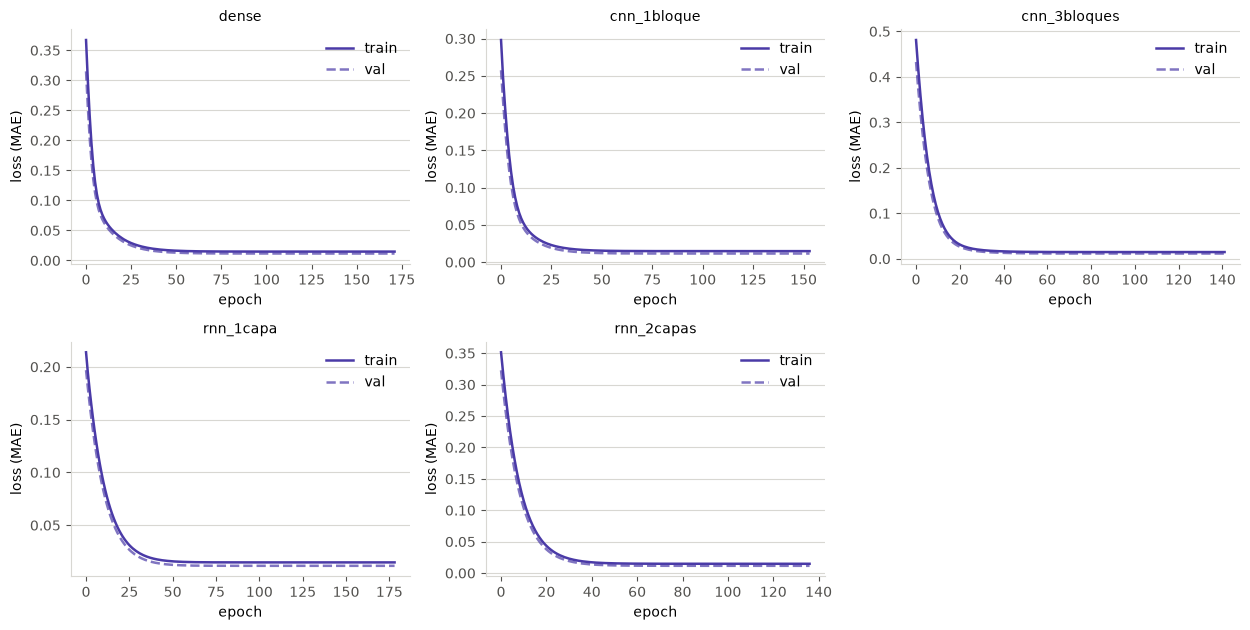

In [5]:
fig = pl.plot_loss_grid(arch_histories, ncols=3)
pl.savefig(fig, "04_loss_curvas_arquitecturas")

Se elige la arquitectura con menor MAE en **validación** (`val_mae`), no
en test: el test se reserva íntegro para la comparación de generadores
del siguiente paso.

La distinción no es cosmética. Elegir entre 7 candidatas por su error de
test es seleccionar sobre el conjunto de evaluación: se acabaría cogiendo
la que mejor encaja con el ruido concreto de ese test, y sus métricas
quedarían sesgadas a la baja. Y como la ganadora se propaga a las dos
rejillas siguientes, el sesgo contaminaría todos los resultados del
trabajo, no solo esta tabla. Se imprimen ambas columnas para que se vea
que la elección no cambia por mirar el test.

In [6]:
ARQUITECTURA_GANADORA = tu.elegir_por_una_ee(arch_results)

# `elegir_por_una_ee` desempata por `n_params`, que es NaN en constante /
# baseline / linear, asi que nunca puede devolver una de ellas: lo que sale
# es siempre una red entrenable. `ARQUITECTURA_RED` es el nombre que usa
# `build_final_model` y se mantiene como alias para dejarlo explicito —
# si algun dia la regla pudiera elegir un modelo sin `.fit` de keras, aqui
# es donde habria que separarlas.
ARQUITECTURA_RED = ARQUITECTURA_GANADORA
mejor_direccional = arch_results["val_directional_accuracy"].idxmax()
print("Ranking por validación (criterio de selección):")
print(arch_results[["val_mae", "val_mae_se", "n_params", "mae"]]
      .sort_values("val_mae").round(6))
print()
_min = arch_results["val_mae"].idxmin()
_umbral = arch_results.loc[_min, "val_mae"] + arch_results.loc[_min, "val_mae_se"]
print(f"Mínimo val_mae: '{_min}' ({arch_results.loc[_min,'val_mae']:.6f}), "
      f"umbral 1 e.e. = {_umbral:.6f}")
print(f"Dentro de 1 e.e.: {list(arch_results[arch_results.val_mae <= _umbral].index)}")
print(f"-> se elige la MÁS SIMPLE de ellas: {ARQUITECTURA_GANADORA}")
print()
if arch_results["mae"].idxmin() != ARQUITECTURA_GANADORA:
    print(f"[NOTA] Por test habría ganado '{arch_results['mae'].idxmin()}'. "
          f"Se mantiene la elección por validación, que es la correcta.")
print("Arquitectura elegida (menor val_mae):", ARQUITECTURA_GANADORA)
if mejor_direccional != ARQUITECTURA_GANADORA:
    print(
        f"[AVISO] '{mejor_direccional}' tiene mejor precisión direccional en "
        f"validación ({arch_results.loc[mejor_direccional, 'val_directional_accuracy']:.3f} vs "
        f"{arch_results.loc[ARQUITECTURA_GANADORA, 'val_directional_accuracy']:.3f}) aunque peor "
        "MAE — vale la pena citar ambas arquitecturas en la presentación."
    )


def build_final_model():
    """Construye la mejor RED con la MISMA regularizacion (`REG`) con la que
    se la selecciono. Si se construyera sin dropout/L2 aqui, la rejilla
    entrenaria un modelo distinto del que gano la comparacion."""
    if ARQUITECTURA_RED == "cnn_1bloque":
        return modelos.build_predictor_cnn(window_x, N_CHANNELS, output_dim, conv_filters=(64,), **REG)
    if ARQUITECTURA_RED == "cnn_3bloques":
        return modelos.build_predictor_cnn(
            window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), **REG
        )
    if ARQUITECTURA_RED == "rnn_1capa":
        return modelos.build_predictor_rnn(window_x, N_CHANNELS, output_dim, lstm_units=(64,), **REG)
    if ARQUITECTURA_RED == "rnn_2capas":
        return modelos.build_predictor_rnn(
            window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), **REG
        )
    if ARQUITECTURA_RED == "dense":
        return modelos.build_predictor_dense(
            window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), **REG
        )
    raise ValueError(f"Arquitectura no keras seleccionada ({ARQUITECTURA_RED}); revisar manualmente.")

Ranking por validación (criterio de selección):
               val_mae  val_mae_se  n_params       mae
model                                                 
constante     0.011518    0.000757       NaN  0.011770
cnn_3bloques  0.011532    0.000755  150273.0  0.011764
dense         0.011532    0.000755  394009.0  0.011764
rnn_2capas    0.011532    0.000755  143681.0  0.011764
cnn_1bloque   0.011533    0.000755  197889.0  0.011764
rnn_1capa     0.011533    0.000755   38465.0  0.011764
baseline      0.017142    0.001002       NaN  0.017367
linear        0.019573    0.001210       NaN  0.019649

Mínimo val_mae: 'constante' (0.011518), umbral 1 e.e. = 0.012275
Dentro de 1 e.e.: ['constante', 'dense', 'cnn_1bloque', 'cnn_3bloques', 'rnn_1capa', 'rnn_2capas']
-> se elige la MÁS SIMPLE de ellas: rnn_1capa

[NOTA] Por test habría ganado 'dense'. Se mantiene la elección por validación, que es la correcta.
Arquitectura elegida (menor val_mae): rnn_1capa
[AVISO] 'constante' tiene mejor precisión d

## 4. Rejilla años de backfill sintético × generador

`synth_years=0` es idéntico para los 4 (sin sintéticos: fila
`solo_reales`, una sola vez); a partir de ahí cada generador aporta su
propio backfill y diverge. Se calcula también el desglose MAE/MSE/
precisión direccional POR BANCO (`ticker_names`), igual que la
comparación final de `Taller_con_Datos_SP500_promedio.ipynb`: una MAE
pooleada sobre los 25 bancos queda dominada por los de mayor volatilidad
(ver notebook 01, GBCI ~1.6x más volátil que JPM).

La función guarda checkpoints en `datos/interim` tras cada combinación. Si
el notebook se interrumpe, al reejecutarlo salta las combinaciones ya
terminadas y continua desde la primera pendiente.

In [8]:
# Un pase por horizonte. Los checkpoints los deja ya escritos
# `scripts/rejilla_paralela.py` (ver §6.10 del README), asi que aqui se
# encuentran hechos y solo se leen; si faltara alguno, se entrenaria.
resultados_h, historias_h, por_banco_h = {}, {}, {}
for h in config.HORIZONTES_DIAS:
    suf = "" if h == config.WINDOW_Y_DAYS else f"_h{h}"
    (Xv, Yv), (Xt, Yt) = val_test[h]
    print(f"\n----- horizonte {h} dia(s) -----")
    resultados_h[h], historias_h[h], por_banco_h[h] = tu.run_depth_grid(
        build_final_model, vistas[h], Xv, Yv, Xt, Yt,
        synth_years_grid=config.SYNTH_DEPTH_YEARS_GRID, train_end=TRAIN_END,
        synth_anchor=config.REAL_INTRADAY_START_DATE,
        epochs=EPOCHS_REJILLA, batch_size=BATCH_SIZE, verbose=0,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        ticker_names=config.PREDICTOR_TICKERS,
        checkpoint_path=config.INTERIM_DIR / f"04_checkpoint_rejilla_profundidad{suf}.csv",
        history_checkpoint_path=config.INTERIM_DIR / f"04_checkpoint_rejilla_profundidad{suf}_histories.json",
        per_ticker_checkpoint_path=config.INTERIM_DIR / f"04_checkpoint_rejilla_profundidad{suf}_por_banco.csv",
    )
    resultados_h[h]["horizonte"] = h
    resultados_h[h].to_csv(config.TABLES_DIR / f"04_resultados_rejilla_profundidad{suf}.csv", index=False)

# El caso base conserva los nombres de siempre
results, histories, per_ticker = (resultados_h[config.WINDOW_Y_DAYS],
                                  historias_h[config.WINDOW_Y_DAYS],
                                  por_banco_h[config.WINDOW_Y_DAYS])

# Tabla unica con los tres horizontes, y el modelo NULO de cada uno como
# referencia: los MAE no son comparables entre horizontes (el target a 30
# dias es ~6x mas pequeno), solo contra la constante de su propio horizonte.
filas_cte = []
for h in config.HORIZONTES_DIAS:
    Xh, Yh, ih, ish = vistas[h][ref_name]
    Xtr_h, Ytr_h, _, _ = tu.slice_by_depth(Xh, Yh, ih, 0, TRAIN_END,
                                           config.REAL_INTRADAY_START_DATE, ish,
                                           embargo_days=EMBARGO_DAYS)
    (_, _), (Xt, Yt) = val_test[h]
    cte = modelos.build_predictor_constant().fit(Xtr_h, Ytr_h)
    m = tu.evaluate_predictor(cte, Xt, Yt)
    filas_cte.append({"horizonte": h, "generator": "constante", "synth_years": np.nan,
                      "n_train": len(Xtr_h), **m})
constantes = pd.DataFrame(filas_cte)
constantes.to_csv(config.TABLES_DIR / "04_constante_por_horizonte.csv", index=False)
print("\nMODELO NULO por horizonte (predecir la media, sin mirar X):")
print(constantes[["horizonte", "n_train", "mae", "directional_accuracy"]].round(6).to_string(index=False))
results.to_csv(config.TABLES_DIR / "04_resultados_rejilla_profundidad.csv")
results.sort_values(["generator", "synth_years"])


----- horizonte 1 dia(s) -----
[depth] saltando solo_reales, synth_years=0: ya existe checkpoint
[depth] saltando noise, synth_years=1: ya existe checkpoint
[depth] saltando gaussian, synth_years=1: ya existe checkpoint
[depth] saltando rbig, synth_years=1: ya existe checkpoint
[depth] saltando gan, synth_years=1: ya existe checkpoint
[depth] saltando noise, synth_years=2: ya existe checkpoint
[depth] saltando gaussian, synth_years=2: ya existe checkpoint
[depth] saltando rbig, synth_years=2: ya existe checkpoint
[depth] saltando gan, synth_years=2: ya existe checkpoint
[depth] saltando noise, synth_years=5: ya existe checkpoint
[depth] saltando gaussian, synth_years=5: ya existe checkpoint
[depth] saltando rbig, synth_years=5: ya existe checkpoint
[depth] saltando gan, synth_years=5: ya existe checkpoint
[depth] saltando noise, synth_years=10: ya existe checkpoint
[depth] saltando gaussian, synth_years=10: ya existe checkpoint
[depth] saltando rbig, synth_years=10: ya existe checkpoi

,generator,synth_years,horizonte,n_train,pct_synth,mse,mae,directional_accuracy
1,gan,1.0,1,1355,0.228782,0.00025,0.011773,0.510164
5,gan,2.0,1,1605,0.348910,0.00025,0.011799,0.489836
9,gan,5.0,1,2362,0.557578,0.00025,0.011762,0.524918
13,gan,10.0,1,3620,0.711326,0.00025,0.011757,0.529180
17,gan,24.0,1,7033,0.851415,0.00025,0.011777,0.500656
2,gaussian,1.0,1,1355,0.228782,0.00025,0.011773,0.510164
6,gaussian,2.0,1,1605,0.348910,0.00025,0.011799,0.494426
10,gaussian,5.0,1,2362,0.557578,0.00025,0.011763,0.520656
14,gaussian,10.0,1,3620,0.711326,0.00025,0.011757,0.526230
18,gaussian,24.0,1,7033,0.851415,0.00025,0.011778,0.503934


WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_mae_vs_profundidad.png')

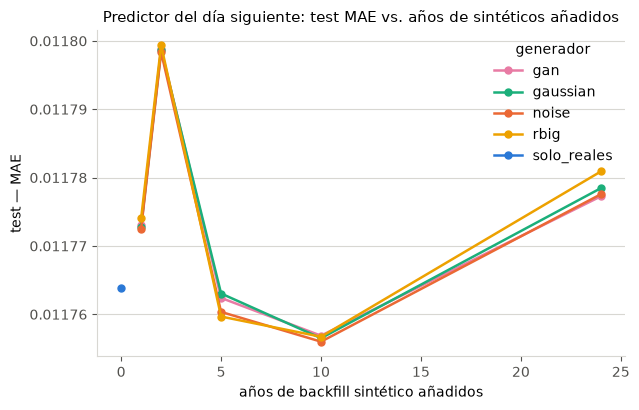

In [9]:
fig = pl.plot_depth_grid_results(results, metric="mae")
pl.savefig(fig, "04_mae_vs_profundidad")

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_mse_vs_profundidad.png')

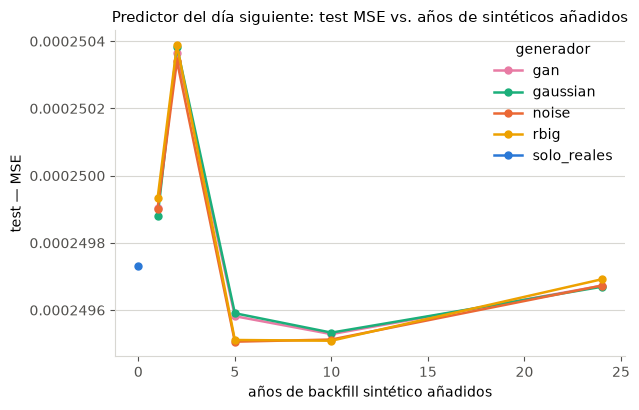

In [10]:
fig = pl.plot_depth_grid_results(results, metric="mse")
pl.savefig(fig, "04_mse_vs_profundidad")

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_precision_direccional_vs_profundidad.png')

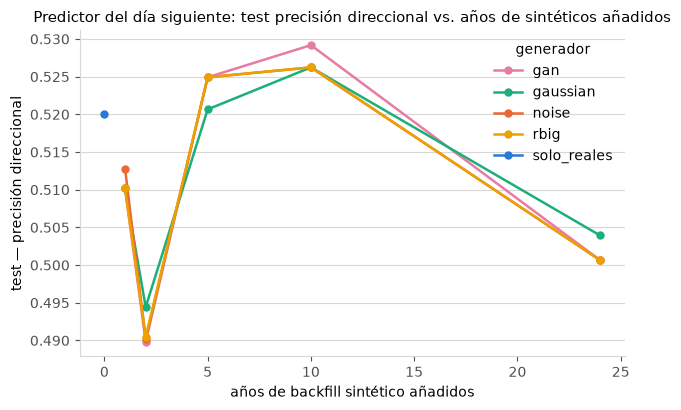

In [11]:
fig = pl.plot_depth_grid_results(results, metric="directional_accuracy")
pl.savefig(fig, "04_precision_direccional_vs_profundidad")

## 5. Rejilla por PORCENTAJE de datos sintéticos × generador

El paso 3 del enunciado pide "datasets que tengan distinto **porcentaje**
de datos sintéticos y reales", y el paso 5 pide ver "cómo meter más o
menos datos sintéticos modifica el comportamiento del modelo". La rejilla
de la sección anterior está expresada en **años** de historia recuperada, que es la rejilla natural del problema financiero, pero traducida a
porcentaje cae en 0% y luego ~57/72/80/84%: todo el tramo 0-57% queda sin
muestrear. Ahí no se puede ver la forma de la curva.

Esta rejilla barre el eje de forma uniforme (`PCT_SYNTH_GRID`),
manteniendo **todas** las filas reales disponibles y añadiendo las
sintéticas más recientes que hagan falta para alcanzar cada proporción
(`train_utils.slice_by_pct`). El caso `pct=1.0` entrena **sin ninguna
fila real**: mide cuánta señal real hace falta como ancla.

Misma arquitectura ganadora, mismos pesos reinicializados, mismo test
real — lo único que cambia entre versiones es la composición del
entrenamiento. Aquí no se calcula desglose por banco porque no se usa en
las salidas de porcentaje; así evitamos predicciones y checkpoints
auxiliares innecesarios.

In [12]:
results_pct, histories_pct, per_ticker_pct = tu.run_pct_grid(
    # `datasets_h1` = vista a 1 dia (tuplas), que es lo que espera run_pct_grid.
    # La rejilla por porcentaje se queda en el horizonte base: es el eje que
    # pide literalmente el enunciado y multiplicarlo por 3 no anade un eje nuevo.
    build_final_model, datasets_h1, X_val, Y_val, X_test, Y_test,
    pct_grid=config.PCT_SYNTH_GRID, train_end=TRAIN_END,
    epochs=EPOCHS_REJILLA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_porcentaje.csv",
    history_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_porcentaje_histories.json",
)
results_pct.to_csv(config.TABLES_DIR / "04_resultados_rejilla_porcentaje.csv")
results_pct.sort_values(["generator", "pct_objetivo"])

[pct] saltando solo_reales, pct=0.0: ya existe checkpoint
[pct] saltando noise, pct=0.25: ya existe checkpoint
[pct] saltando gaussian, pct=0.25: ya existe checkpoint
[pct] saltando rbig, pct=0.25: ya existe checkpoint
[pct] saltando gan, pct=0.25: ya existe checkpoint
[pct] saltando noise, pct=0.5: ya existe checkpoint
[pct] saltando gaussian, pct=0.5: ya existe checkpoint
[pct] saltando rbig, pct=0.5: ya existe checkpoint
[pct] saltando gan, pct=0.5: ya existe checkpoint
[pct] saltando noise, pct=0.75: ya existe checkpoint
[pct] saltando gaussian, pct=0.75: ya existe checkpoint
[pct] saltando rbig, pct=0.75: ya existe checkpoint
[pct] saltando gan, pct=0.75: ya existe checkpoint
[pct] saltando noise, pct=0.9: ya existe checkpoint
[pct] saltando gaussian, pct=0.9: ya existe checkpoint
[pct] saltando rbig, pct=0.9: ya existe checkpoint
[pct] saltando gan, pct=0.9: ya existe checkpoint
[pct] saltando noise, pct=1.0: ya existe checkpoint
[pct] saltando gaussian, pct=1.0: ya existe checkp

,generator,pct_objetivo,horizonte,n_train,pct_synth,mse,mae,directional_accuracy
1,gan,0.25,1,1393,0.249821,0.00025,0.011785,0.504918
5,gan,0.50,1,2090,0.500000,0.00025,0.011771,0.522295
9,gan,0.75,1,4180,0.750000,0.00025,0.011778,0.509508
13,gan,0.90,1,7033,0.851415,0.00025,0.011777,0.500656
17,gan,1.00,1,5988,1.000000,0.00025,0.011760,0.527213
2,gaussian,0.25,1,1393,0.249821,0.00025,0.011784,0.509508
6,gaussian,0.50,1,2090,0.500000,0.00025,0.011772,0.520000
10,gaussian,0.75,1,4180,0.750000,0.00025,0.011777,0.509508
14,gaussian,0.90,1,7033,0.851415,0.00025,0.011778,0.503934
18,gaussian,1.00,1,5988,1.000000,0.00025,0.011761,0.527213


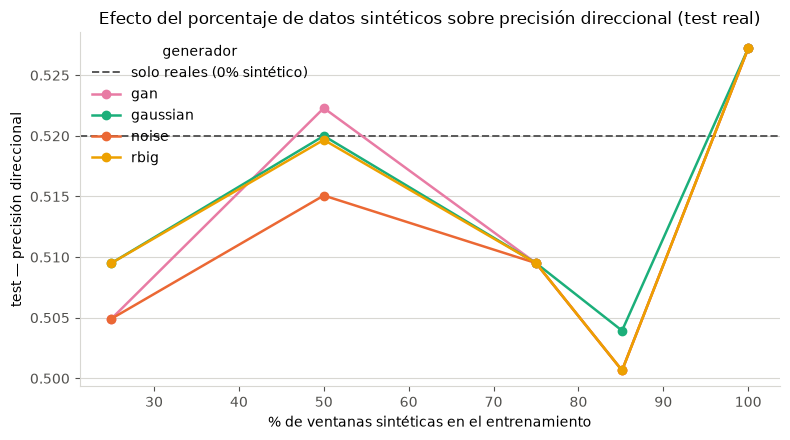

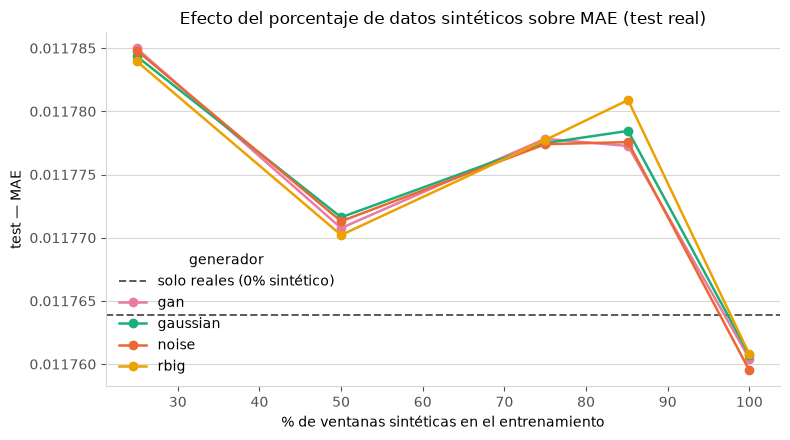

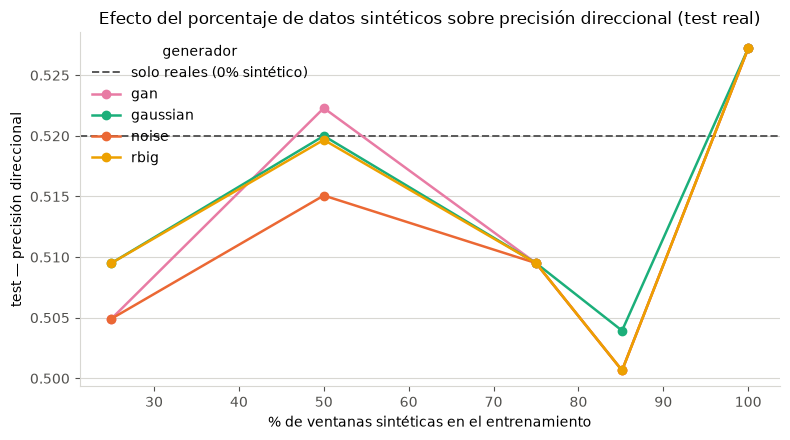

In [13]:
for metrica, nombre_fig in [
    ("mae", "04_mae_vs_porcentaje"),
    ("directional_accuracy", "04_precision_direccional_vs_porcentaje"),
]:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    solo_reales = results_pct[results_pct.generator == "solo_reales"]
    if not solo_reales.empty:
        ax.axhline(
            solo_reales[metrica].iloc[0], color="0.35", linestyle="--", linewidth=1.4,
            label="solo reales (0% sintético)",
        )
    for gen_name, sub in results_pct[results_pct.generator != "solo_reales"].groupby("generator"):
        sub = sub.sort_values("pct_synth")
        ax.plot(sub.pct_synth * 100, sub[metrica], marker="o", linewidth=1.8,
                color=pl.color_for(gen_name), label=gen_name)
    ax.set_xlabel("% de ventanas sintéticas en el entrenamiento")
    ax.set_ylabel(f"test — {pl.metric_label(metrica)}")
    ax.set_title(
        f"Efecto del porcentaje de datos sintéticos sobre "
        f"{pl.metric_label(metrica)} (test real)"
    )
    ax.legend(frameon=False, title="generador")
    pl.style_axes(ax)
    fig.tight_layout()
    pl.savefig(fig, nombre_fig)

fig

## 6. Desglose por banco a máxima profundidad sintética

Gráfico de barras agrupado MAE por banco y generador (misma idea que el
bloque final de `Taller_con_Datos_SP500_promedio.ipynb`), en el punto de
mayor profundidad de la rejilla.

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_mae_por_banco.png')

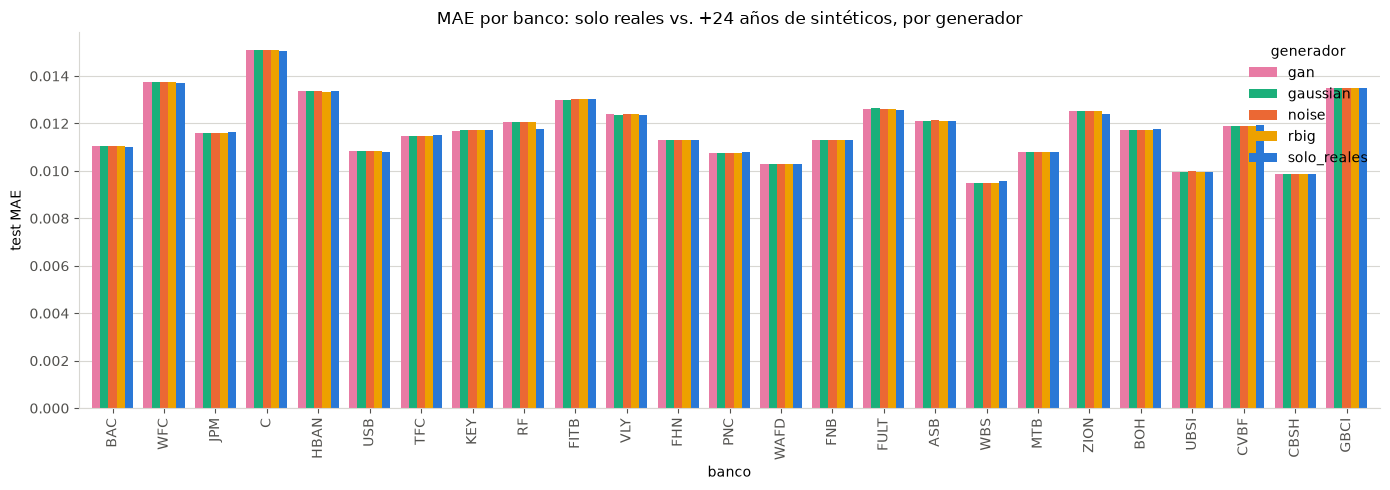

In [14]:
synth_years_max = config.SYNTH_DEPTH_YEARS_GRID[-1]
per_ticker_final = {
    gen_name: df for (gen_name, sy), df in per_ticker.items() if sy == synth_years_max
}
per_ticker_final["solo_reales"] = per_ticker[("solo_reales", config.SYNTH_DEPTH_YEARS_GRID[0])]

per_ticker_table = pd.concat(
    {name: df["mae"] for name, df in per_ticker_final.items()}, axis=1
)
per_ticker_table.to_csv(config.TABLES_DIR / "04_mae_por_banco.csv")

fig, ax = plt.subplots(figsize=(14, 5))
per_ticker_table.plot(
    kind="bar", ax=ax,
    color=[pl.color_for(c) for c in per_ticker_table.columns],
    width=0.8,
)
ax.set_ylabel("test MAE")
ax.set_xlabel("banco")
ax.set_title(f"MAE por banco: solo reales vs. +{synth_years_max} años de sintéticos, por generador")
ax.legend(frameon=False, title="generador")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "04_mae_por_banco")

## 7. Curvas de loss de **todos** los entrenamientos

El enunciado exige, literalmente, "para **cada** entrenamiento, incluir
las curvas de loss donde se vea que el modelo ha convergido" — no una
muestra representativa. Así que aquí se vuelcan las tres tandas
completas: las 7 arquitecturas candidatas (sección 3), los
`4 × (len(SYNTH_DEPTH_YEARS_GRID)-1) + 1` de la rejilla por años y los
de la rejilla por porcentaje. Cada panel lleva el mismo criterio de
parada (`EarlyStopping` con paciencia alta), así que el tramo plano
final es la evidencia de convergencia que se pide.

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_loss_curvas_rejilla.png')

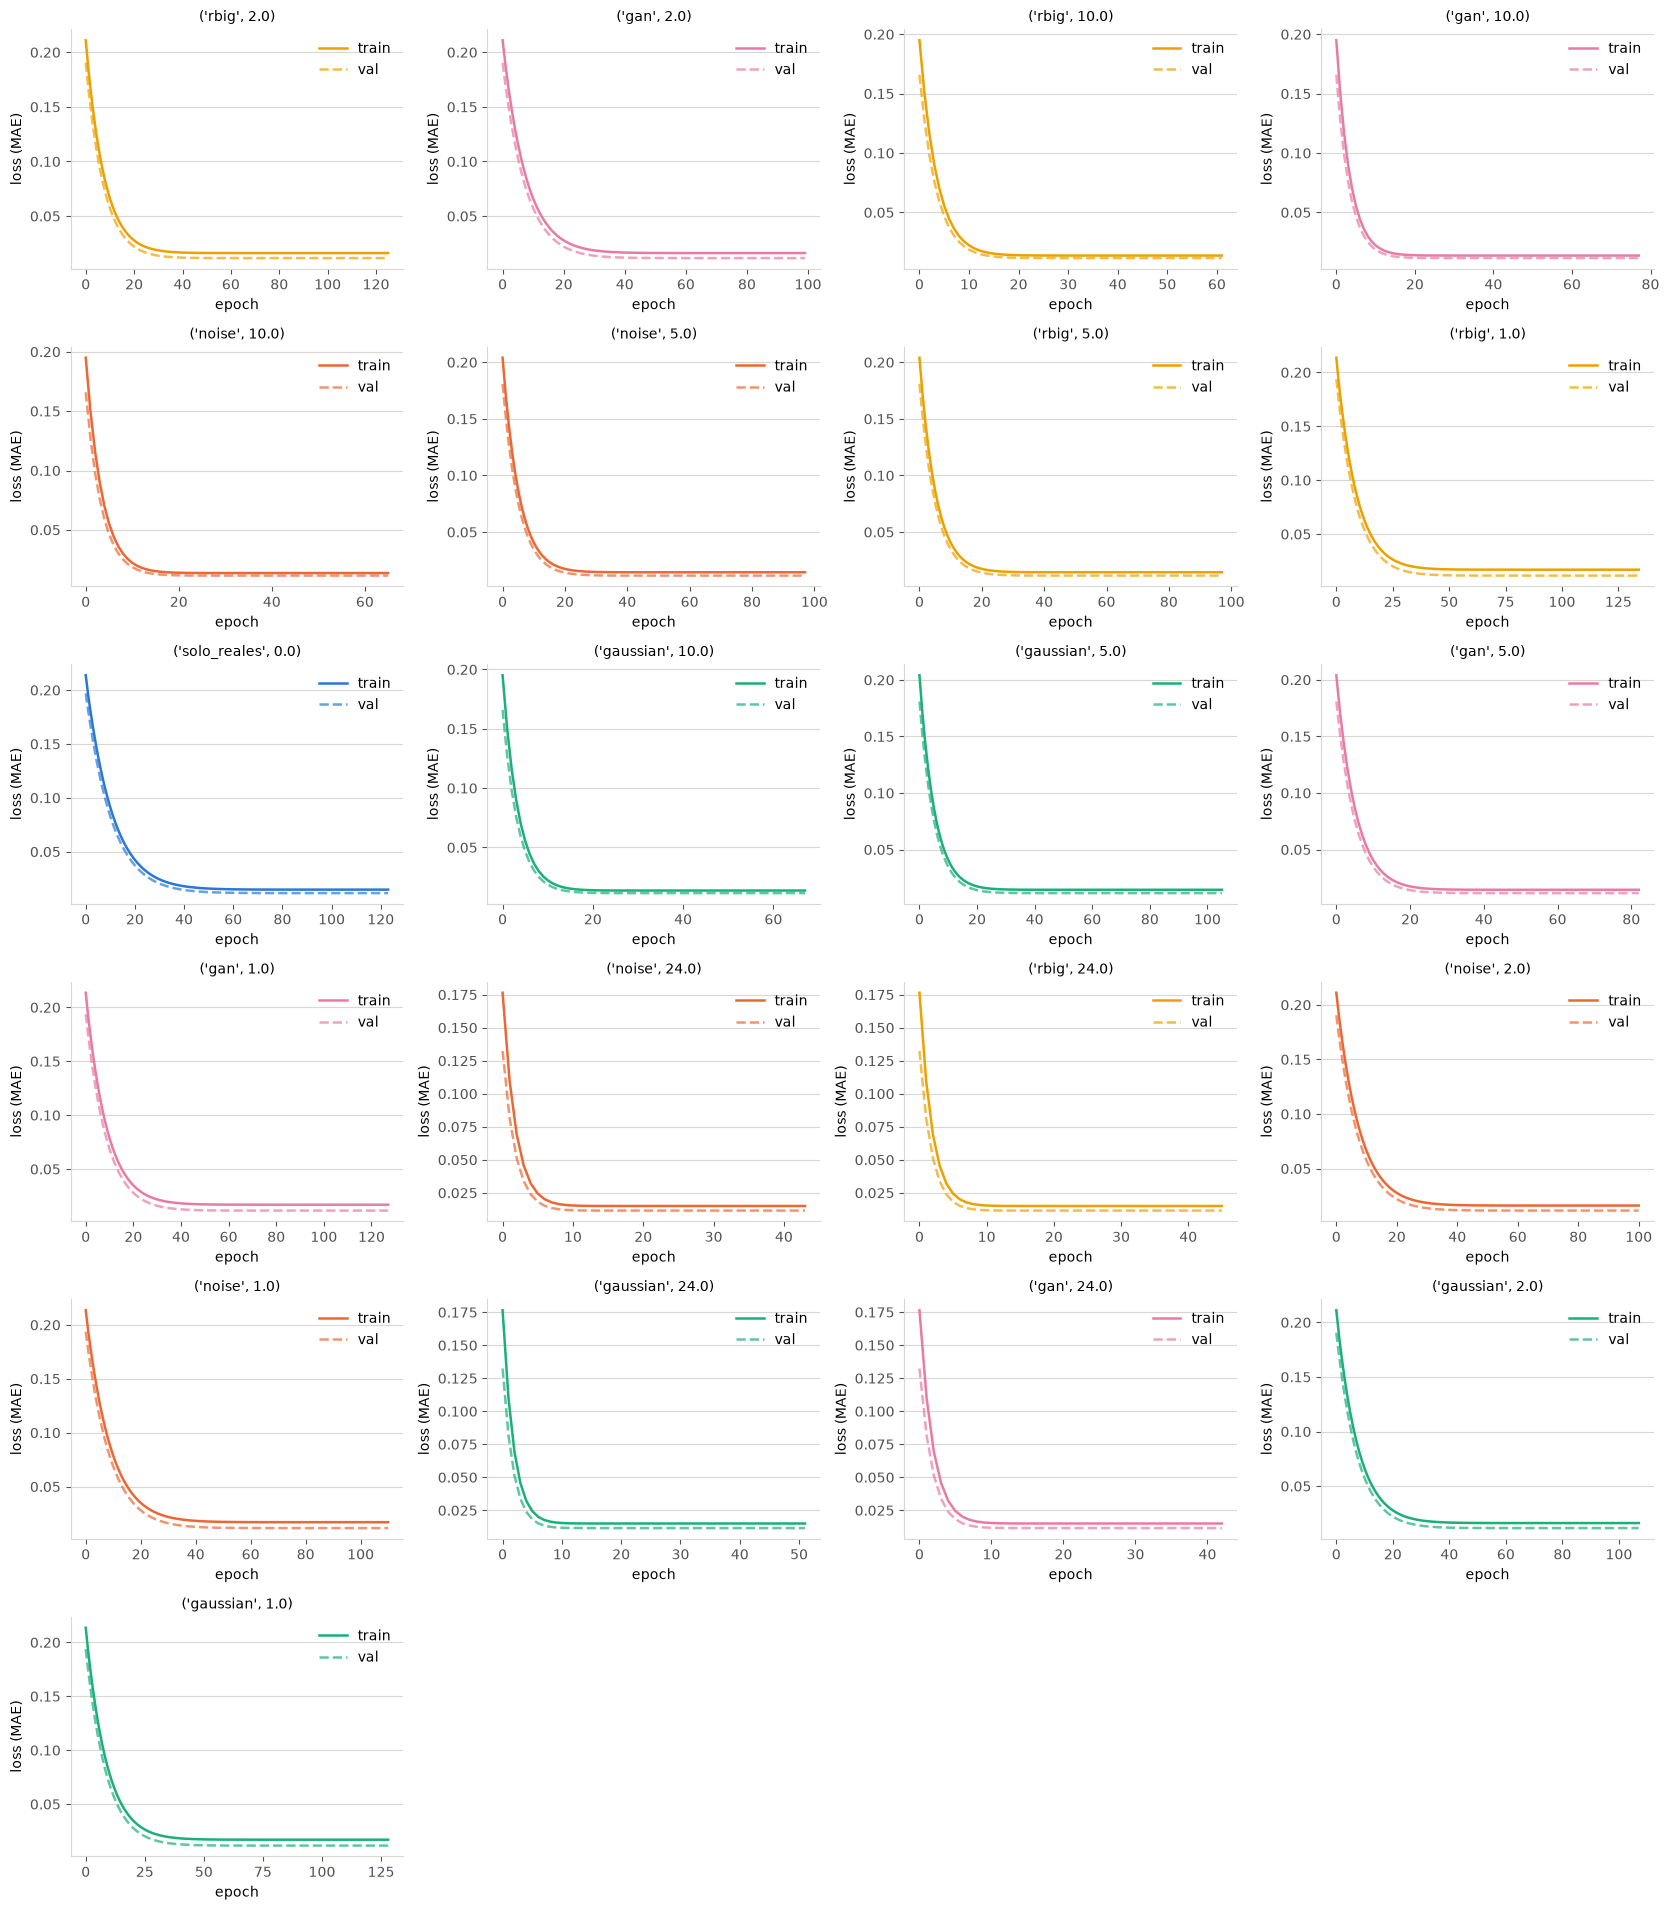

In [18]:
fig = pl.plot_loss_grid(histories, ncols=4)
pl.savefig(fig, "04_loss_curvas_rejilla")

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_loss_curvas_porcentaje.png')

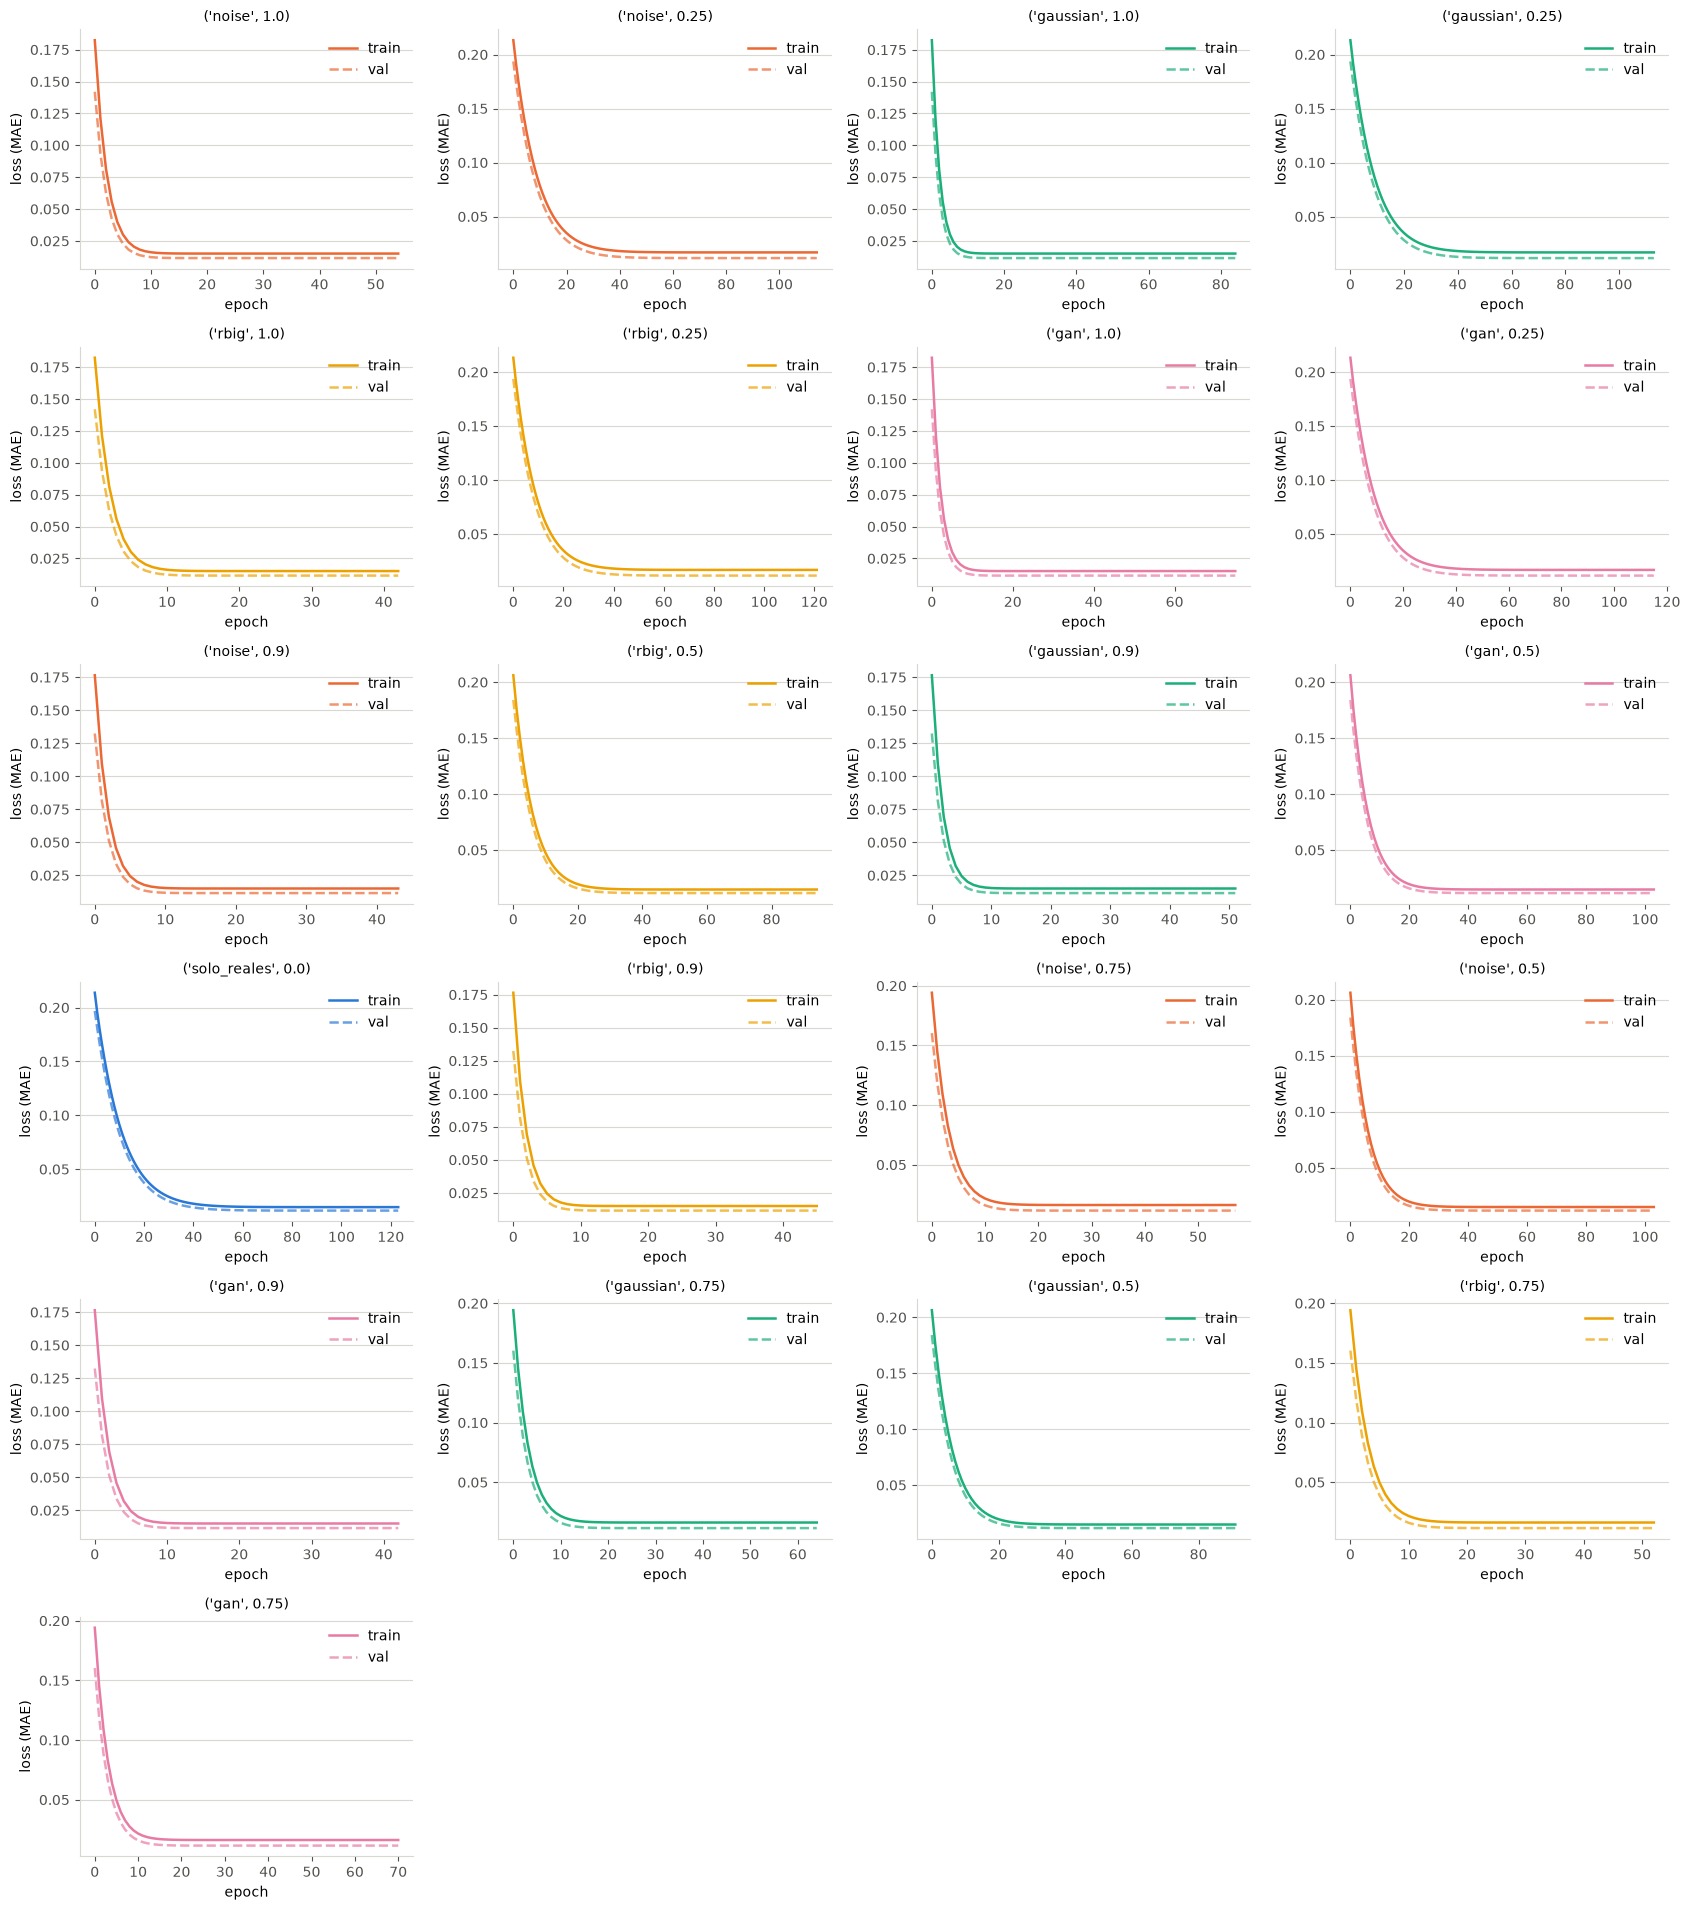

In [19]:
fig = pl.plot_loss_grid(histories_pct, ncols=4)
pl.savefig(fig, "04_loss_curvas_porcentaje")

## 8. Guardar resultados consolidados (`datos/interim/`, gitignored)

El notebook 05 solo lee estos CSV/tablas — no vuelve a entrenar nada.

In [17]:
results.to_pickle(config.INTERIM_DIR / "resultados_finales.pkl")
results_pct.to_pickle(config.INTERIM_DIR / "resultados_porcentaje.pkl")
per_ticker_table.to_pickle(config.INTERIM_DIR / "resultados_por_banco.pkl")
print("Listo. Tablas en reports/tables/04_resultados_rejilla_profundidad.csv"
      " y 04_resultados_rejilla_porcentaje.csv")

Listo. Tablas en reports/tables/04_resultados_rejilla_profundidad.csv y 04_resultados_rejilla_porcentaje.csv
